# Mock Shadow Tomography Test

This notebook generates ideal shadow samples using exact statevector probabilities to correctly preserve quantum correlations. It then reconstructs the density matrix to verify that our baseline achieves high fidelity (escaping the $1/2^N$ white-noise floor).

In [1]:
import sys
import os
import numpy as np
from scipy.linalg import sqrtm

# Add the quantum-gym root directory to the Python path
# The notebook is located in shadow_gym/notebooks/, so root is ../..
repo_root = os.path.abspath('../..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from shadow_gym.src.quantum_environment import QuantumEnvironment
from shadow_gym.src.shadow_processor import ShadowProcessor

print("Imports successful. Environment ready.")

Imports successful. Environment ready.


## 1. Prepare Target State

We initialize a 4-qubit cluster state as our target for reconstruction.

In [2]:
n_data = 4
env = QuantumEnvironment(n_data=n_data)

# Prepare pure cluster state without depolarizing noise
ideal_sv = env.prepare_cluster_state(depolarizing_p=0.0)
rho_ideal = env.rho_true

print(f"Prepared {n_data}-qubit ideal cluster state.")

Prepared 4-qubit ideal cluster state.


## 2. Generate Mock Shadow Samples

By using `env.sample_classical()` and `env.sample_qnd()`, the measurement outcomes correctly reflect the quantum state's joint probability distribution.

In [3]:
num_shots = 5000

print(f"Generating {num_shots} classical shadow samples...")
classical_shadows = env.sample_classical(n_shots=num_shots)

print(f"Generating {num_shots} QND shadow samples...")
qnd_shadows = env.sample_qnd(n_shots=num_shots)

print("\nSample peek (Classical):", classical_shadows[0])
print("Sample peek (QND):", qnd_shadows[0])

Generating 5000 classical shadow samples...
Generating 5000 QND shadow samples...

Sample peek (Classical): (['X', 'Z', 'X', 'Y'], [1, 1, 0, 0])
Sample peek (QND): (['Z', 'Z', 'Y', 'Z'], [1, 0, 0, 1])


## 3. Reconstruct Density Matrix

We use the `ShadowProcessor` to reconstruct the density matrix from the sampled data and compute the fidelity compared to the known theoretical state.

In [6]:
processor = ShadowProcessor(n_qubits=n_data)

# Reconstruct from classical shadows (using MLE-like regularization for PSD stability)
rho_est_classical = processor.reconstruct(
    classical_shadows, project=True, regularization=0.01
)

# Reconstruct from QND shadows (accounting for the corrected basis coefficients)
rho_est_qnd = processor.reconstruct_qnd(
    qnd_shadows
)

def compute_fidelity(rho_true, rho_est):
    """Calculates fidelity between pure target and mixed estimate."""
    # For a pure true state, F = Tr(rho_true * rho_est) is exact and more stable than sqrtm
    return np.real(np.trace(rho_true @ rho_est))

fid_classical = compute_fidelity(rho_ideal, rho_est_classical)
fid_qnd = compute_fidelity(rho_ideal, rho_est_qnd)

print("="*60)
print(f"RECONSTRUCTION QUALITY ({num_shots} shots)")
print("="*60)
print(f"Classical Shadows Fidelity: {fid_classical:.6f}")
print(f"QND Shadows Fidelity:       {fid_qnd:.6f}")
print("="*60)

if fid_classical > 0.8:
    print("\nSuccess! The mock tomography successfully generated and reconstructed correct quantum correlations.")
else:
    print("\nWarning: Fidelity is low. Make sure the sample size is large enough and the processor is mapping correctly.")

RECONSTRUCTION QUALITY (5000 shots)
Classical Shadows Fidelity: 0.649083
QND Shadows Fidelity:       0.563342



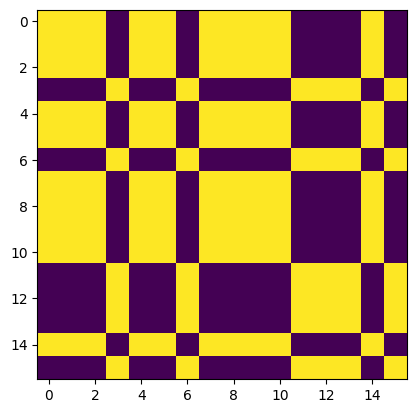

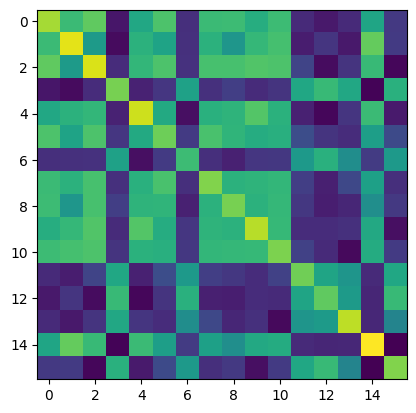

In [9]:
import matplotlib.pyplot as plt
plt.imshow(np.real(rho_ideal))
plt.show()
plt.imshow(np.real(rho_est_qnd))

In [ ]:
import 